# 📊 Data Profiling — AI-Powered Banking Support & Fraud Intelligence System
**Project:** NLP + RAG Banking Support System  
**Phase:** 1 · Data Exploration & Profiling  

---
### Datasets profiled
| # | File | Type | Purpose |
|---|------|------|---------|
| 1 | `01_support_tickets.csv` | Structured | Intent classification, RAG source |
| 2 | `02_transactions.csv` | Structured | Fraud risk classification |
| 3 | `04_qa_pairs.json` | Semi-structured | RAG QA knowledge base |
| 4 | `policy_docs/` | Unstructured | RAG policy retrieval |


## 0 · Imports & Configuration

In [15]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from collections import Counter

warnings.filterwarnings("ignore")
PROJECT_ROOT = Path(os.getcwd())


# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "figure.facecolor": "white",
})
PALETTE = ["#2563EB", "#16A34A", "#DC2626", "#D97706", "#7C3AED", "#0891B2"]

# ── Paths ─────────────────────────────────────────────────────────────────────
RAW = Path("../data/raw")
TICKETS_PATH  = RAW / "01_support_tickets.csv"
TXN_PATH      = RAW / "02_transactions.csv"
QA_PATH       = RAW / "04_qa_pairs.json"
POLICY_DIR    = RAW / "policy_docs"

print("✅ Setup complete")


✅ Setup complete


## 1 · Helper Functions

In [16]:
def section(title: str) -> None:
    """Print a visible section divider."""
    print(f"\n{'='*60}")
    print(f"  {title}")
    print('='*60)


def quick_profile(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """
    Return a tidy profile DataFrame for a given DataFrame.
    Columns: dtype | non_null | null_count | null_pct | unique | sample_values
    """
    rows = []
    for col in df.columns:
        series = df[col]
        null_count = series.isna().sum()
        rows.append({
            "column"       : col,
            "dtype"        : str(series.dtype),
            "non_null"     : series.notna().sum(),
            "null_count"   : null_count,
            "null_pct"     : round(null_count / len(df) * 100, 2),
            "unique"       : series.nunique(),
            "sample_values": str(series.dropna().unique()[:3].tolist()),
        })
    profile = pd.DataFrame(rows).set_index("column")
    section(f"Profile — {name}  ({df.shape[0]:,} rows × {df.shape[1]} cols)")
    display(profile)
    return profile


def plot_nulls(df: pd.DataFrame, title: str) -> None:
    """Bar chart of null percentages per column (skips cols with 0% nulls)."""
    null_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
    null_pct = null_pct[null_pct > 0]
    if null_pct.empty:
        print(f"  ✅ No nulls found in {title}")
        return
    fig, ax = plt.subplots(figsize=(8, 3))
    bars = ax.barh(null_pct.index, null_pct.values, color=PALETTE[2])
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
    ax.set_xlabel("Null %")
    ax.set_title(f"Null % per column — {title}")
    plt.tight_layout()
    plt.show()


print("✅ Helpers defined")


✅ Helpers defined


## 2 · Support Tickets  (`01_support_tickets.csv`)

In [17]:
tickets = pd.read_csv(TICKETS_PATH)
_ = quick_profile(tickets, "Support Tickets")



  Profile — Support Tickets  (200 rows × 14 cols)


,dtype,non_null,null_count,null_pct,unique,sample_values
column,,,,,,
ticket_id,object,200,0,0.0,200,"['TKT-10001', 'TKT-10002', 'TKT-10003']"
date_created,object,200,0,0.0,149,"['2023-03-13', '2023-11-05', '2023-08-05']"
customer_id,object,200,0,0.0,200,"['CUST872246', 'CUST127824', 'CUST456778']"
channel,object,200,0,0.0,5,"['Web Chat', 'Branch', 'Phone']"
category,object,200,0,0.0,4,"['Fraud/Unauthorized', 'Loan', 'KYC']"
sub_category,object,200,0,0.0,40,"[""I see a transaction of ₹{amt} I didn't m"", ""..."
query_text,object,200,0,0.0,66,"[""I see a transaction of ₹999 I didn't make on..."
sentiment,object,200,0,0.0,6,"['Urgent', 'Neutral', 'Confused']"
risk_level,object,200,0,0.0,3,"['High', 'Medium', 'Low']"


In [18]:
# ── Numeric columns descriptive stats ─────────────────────────────────────────
num_cols_tickets = tickets.select_dtypes(include='number').columns.tolist()

print("Numeric columns descriptive stats — Support Tickets:")
display(tickets[num_cols_tickets].describe().T.round(2))

Numeric columns descriptive stats — Support Tickets:


,count,mean,std,min,25%,50%,75%,max
resolution_time_minutes,200.0,90.78,66.18,6.0,38.5,72.0,140.5,240.0
customer_satisfaction,200.0,3.93,0.89,2.0,3.0,4.0,5.0,5.0


Detected 6 categorical columns: ['channel', 'category', 'sentiment', 'risk_level', 'resolved_by', 'escalated']


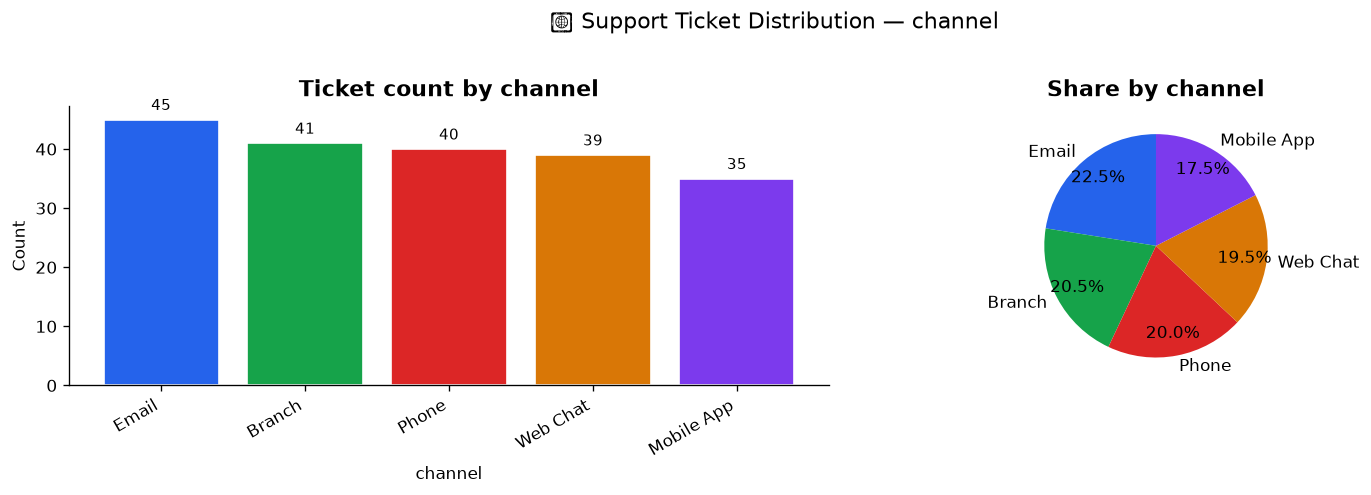


Value counts — channel  (5 unique):


,count
channel,
Email,45
Branch,41
Phone,40
Web Chat,39
Mobile App,35


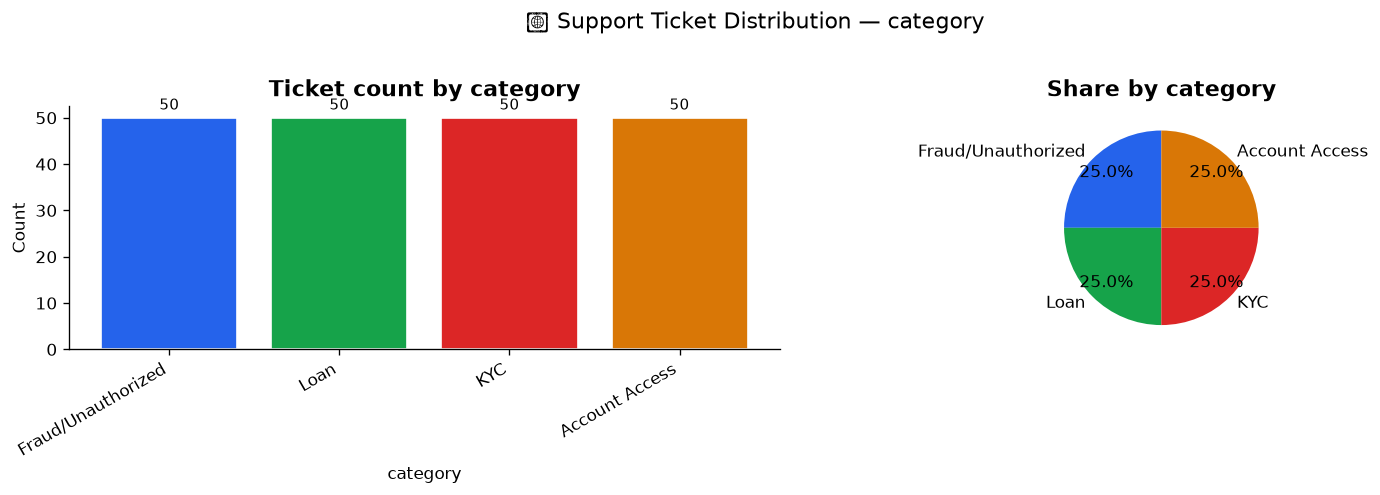


Value counts — category  (4 unique):


,count
category,
Fraud/Unauthorized,50
Loan,50
KYC,50
Account Access,50


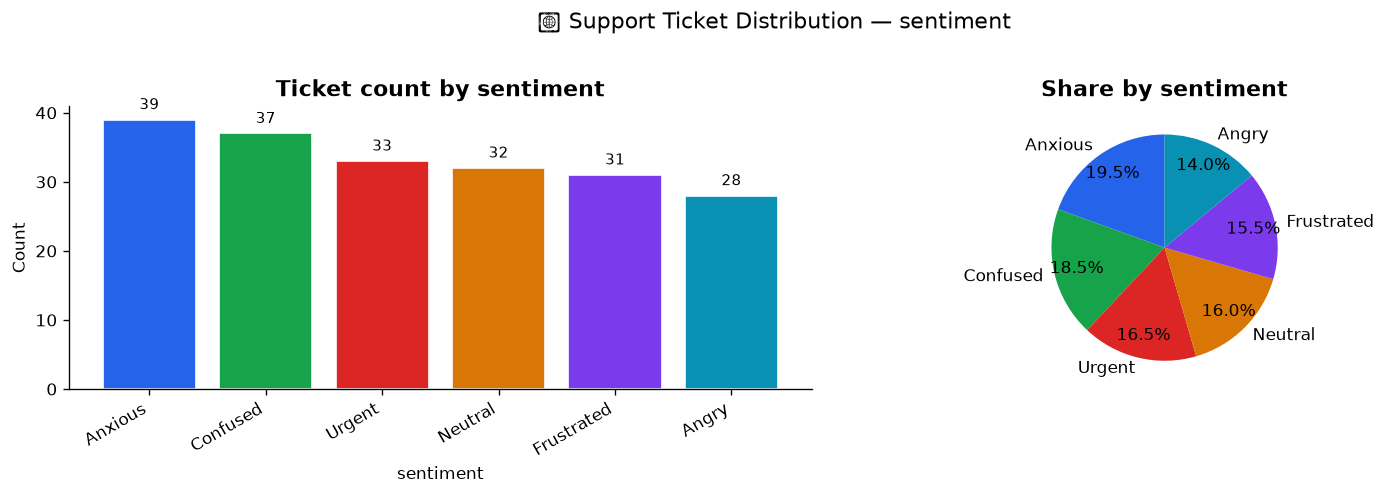


Value counts — sentiment  (6 unique):


,count
sentiment,
Anxious,39
Confused,37
Urgent,33
Neutral,32
Frustrated,31
Angry,28


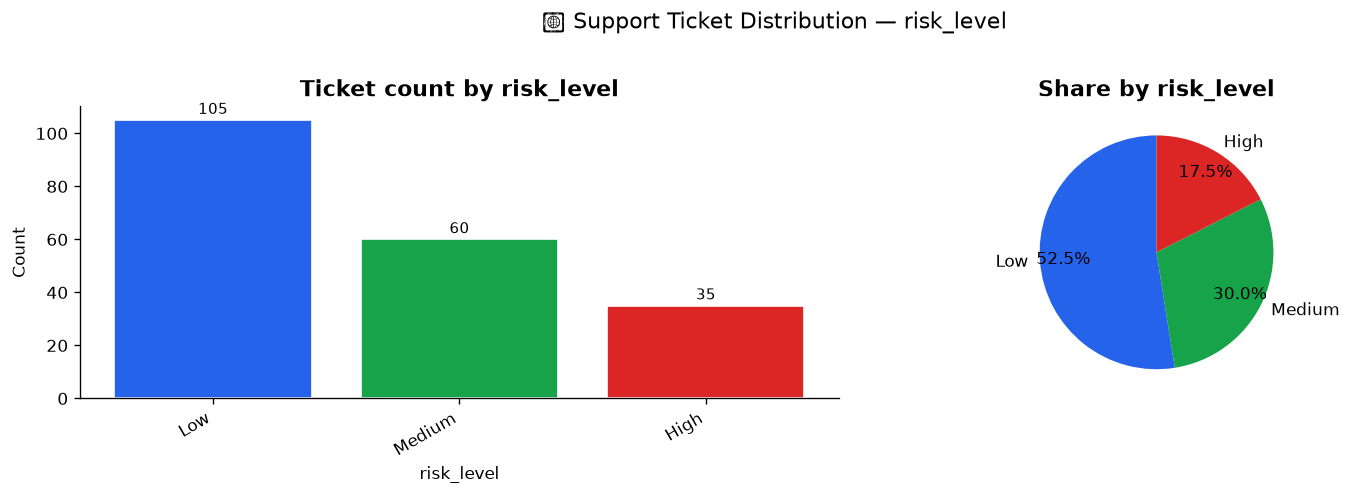


Value counts — risk_level  (3 unique):


,count
risk_level,
Low,105
Medium,60
High,35


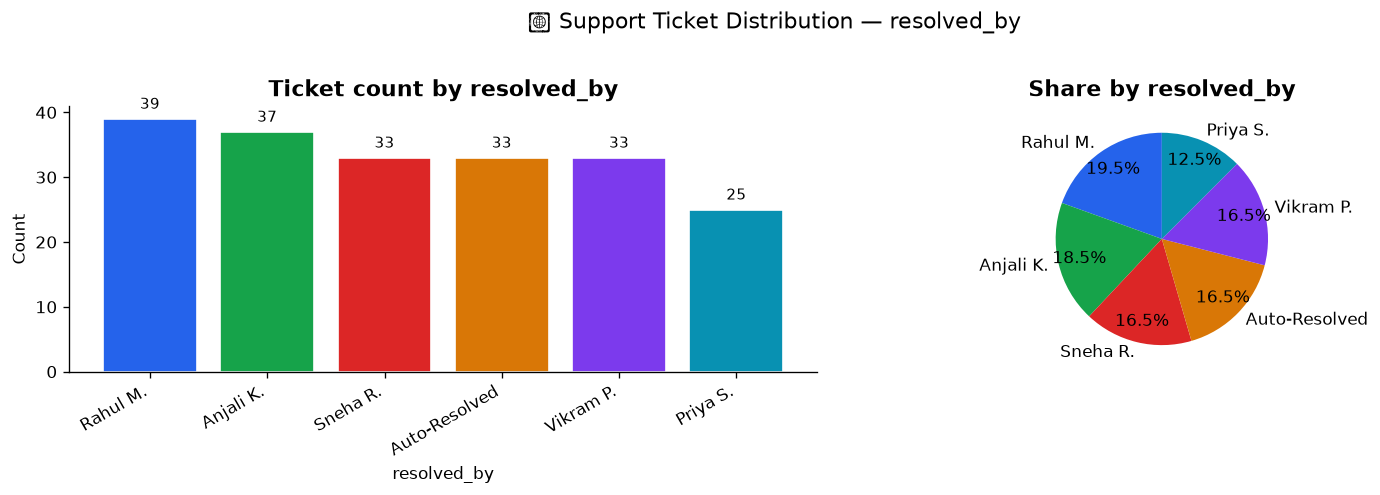


Value counts — resolved_by  (6 unique):


,count
resolved_by,
Rahul M.,39
Anjali K.,37
Sneha R.,33
Auto-Resolved,33
Vikram P.,33
Priya S.,25


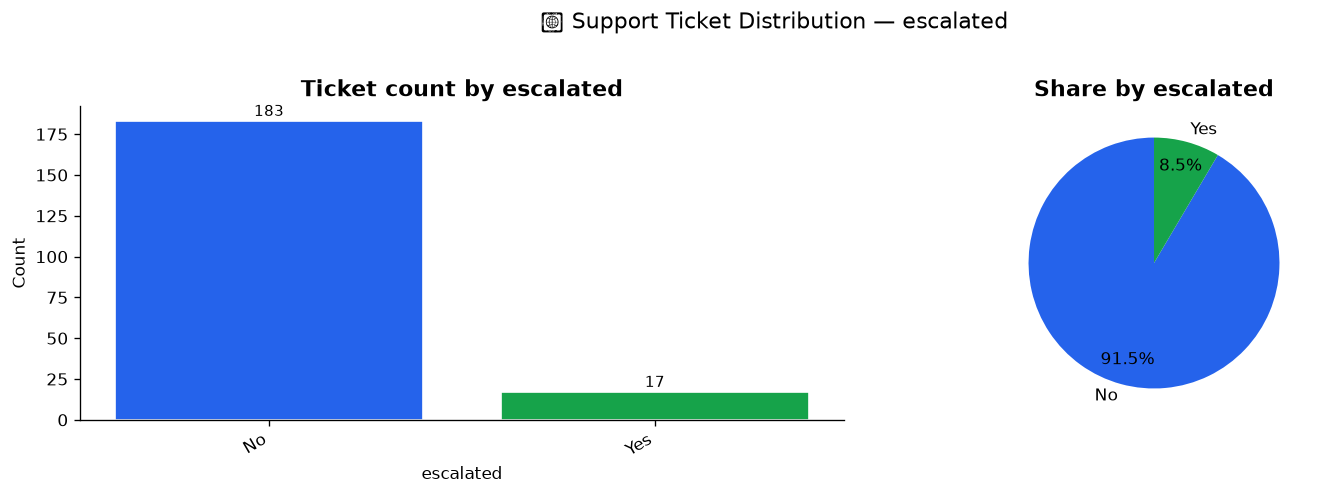


Value counts — escalated  (2 unique):


,count
escalated,
No,183
Yes,17


In [19]:
# ── Category distribution ─────────────────────────────────────────────────────
def is_categorical(series: pd.Series, max_unique_ratio: float = 0.05) -> bool:
    if isinstance(series.dtype, pd.CategoricalDtype):
        return True
    if not (series.dtype == object or isinstance(series.dtype, pd.StringDtype)):
        return False
    n_unique = series.nunique()
    return n_unique < 50 or (n_unique / len(series)) < max_unique_ratio

cat_cols = [c for c in tickets.columns if is_categorical(tickets[c])]
cat_cols = [c for c in cat_cols if tickets[c].dropna().str.len().mean() < 35]

print(f"Detected {len(cat_cols)} categorical columns: {cat_cols}")

if not cat_cols:
    print("⚠️  No categorical columns detected — check dtype or cardinality thresholds")
else:
    TOP_N = 10          # tune this if needed
    CARDINALITY_LIMIT = 20   # columns with more unique values than this → bar only, no pie

    for cat_col in cat_cols:
        counts = tickets[cat_col].value_counts()
        labels = [str(v) for v in counts.index]
        values = counts.values
        n_unique = len(labels)
        high_cardinality = n_unique > CARDINALITY_LIMIT

        if high_cardinality:
            # ── High cardinality: bar only, top N ────────────────────────────────
            top_labels = labels[:TOP_N]
            top_values = values[:TOP_N]

            fig, ax = plt.subplots(figsize=(10, 4))
            x = range(len(top_labels))
            bars = ax.bar(x, top_values, color=PALETTE[:len(top_values)], edgecolor="white")
            ax.set_xticks(list(x))
            ax.set_xticklabels(top_labels, rotation=30, ha="right")
            ax.set_title(f"Top {TOP_N} of {n_unique} values — {cat_col}")
            ax.set_xlabel(cat_col)
            ax.set_ylabel("Count")
            for bar, val in zip(bars, top_values):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 1, str(val),
                        ha="center", va="bottom", fontsize=9)
            plt.suptitle(f"📋 {cat_col}  ({n_unique} unique values — showing top {TOP_N})",
                        fontsize=13, y=1.02)
            plt.tight_layout()
            plt.show()

        else:
            # ── Low cardinality: bar + pie side by side ───────────────────────────
            fig, axes = plt.subplots(1, 2, figsize=(13, 4))

            x = range(len(labels))
            bars = axes[0].bar(x, values, color=PALETTE[:len(values)], edgecolor="white")
            axes[0].set_xticks(list(x))
            axes[0].set_xticklabels(labels, rotation=30, ha="right")
            axes[0].set_title(f"Ticket count by {cat_col}")
            axes[0].set_xlabel(cat_col)
            axes[0].set_ylabel("Count")
            for bar, val in zip(bars, values):
                axes[0].text(bar.get_x() + bar.get_width() / 2,
                            bar.get_height() + 1, str(val),
                            ha="center", va="bottom", fontsize=9)

            axes[1].pie(values, labels=labels,
                        autopct="%1.1f%%", colors=PALETTE[:len(values)],
                        startangle=90, pctdistance=0.8)
            axes[1].set_title(f"Share by {cat_col}")

            plt.suptitle(f"📋 Support Ticket Distribution — {cat_col}", fontsize=13, y=1.02)
            plt.tight_layout()
            plt.show()

        # Always show full value counts table
        print(f"\nValue counts — {cat_col}  ({n_unique} unique):")
        display(counts.to_frame("count"))

In [20]:
# ── Query / resolution text length distribution ───────────────────────────────
text_cols = [
    c for c in tickets.columns
    if str(tickets[c].dtype) == "str"
    and tickets[c].dropna().str.len().mean() > 45
]

if text_cols:
    fig, axes = plt.subplots(1, len(text_cols), figsize=(6 * len(text_cols), 4))
    if len(text_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, text_cols):
        lengths = tickets[col].dropna().str.len()
        ax.hist(lengths, bins=40, color=PALETTE[0], edgecolor="white", alpha=0.85)
        ax.axvline(lengths.mean(), color=PALETTE[2], linestyle="--",
                   label=f"Mean {lengths.mean():.0f}")
        ax.axvline(lengths.median(), color=PALETTE[3], linestyle="--",
                   label=f"Median {lengths.median():.0f}")
        ax.set_title(f"Text length — '{col}'")
        ax.set_xlabel("Characters")
        ax.set_ylabel("Frequency")
        ax.legend(fontsize=8)
    plt.suptitle("📝 Text Length Distribution (Query / Resolution)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


Date range: 2023-01-01 → 2023-12-27
Span: 360 days


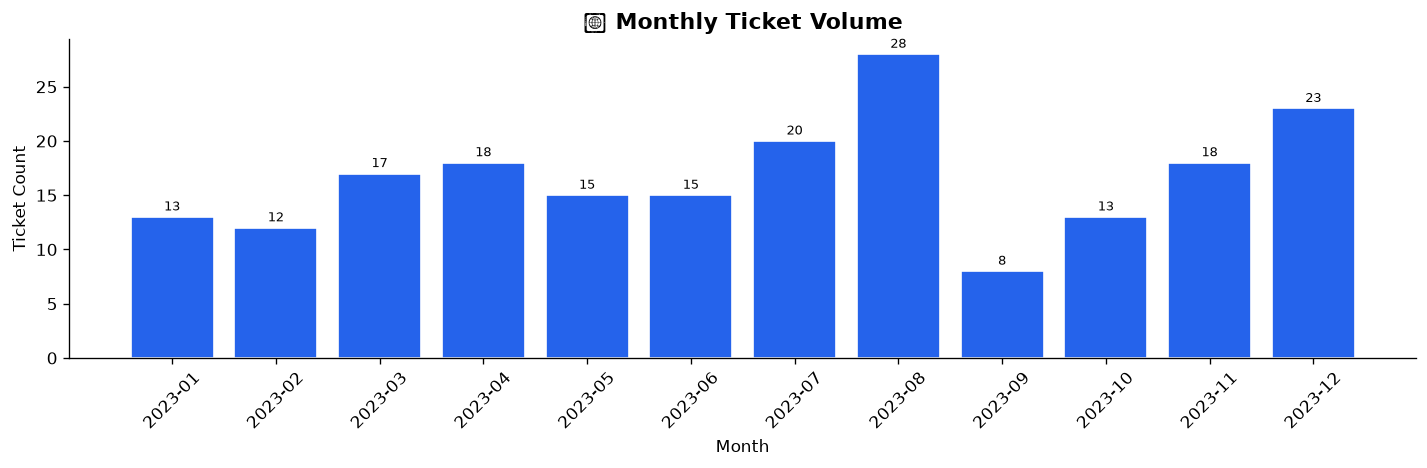

In [21]:
# ── Date analysis ─────────────────────────────────────────────────────────────
tickets["date_created"] = pd.to_datetime(tickets["date_created"], errors="coerce")

print(f"Date range: {tickets['date_created'].min().date()} → {tickets['date_created'].max().date()}")
print(f"Span: {(tickets['date_created'].max() - tickets['date_created'].min()).days} days")

# Monthly ticket volume
tickets["year_month"] = tickets["date_created"].dt.to_period("M")
monthly = tickets.groupby("year_month").size()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly.index.astype(str), monthly.values,
       color=PALETTE[0], edgecolor="white")
ax.set_title("📅 Monthly Ticket Volume")
ax.set_xlabel("Month")
ax.set_ylabel("Ticket Count")
ax.tick_params(axis="x", rotation=45)
for bar, val in zip(ax.patches, monthly.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3, str(val),
            ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

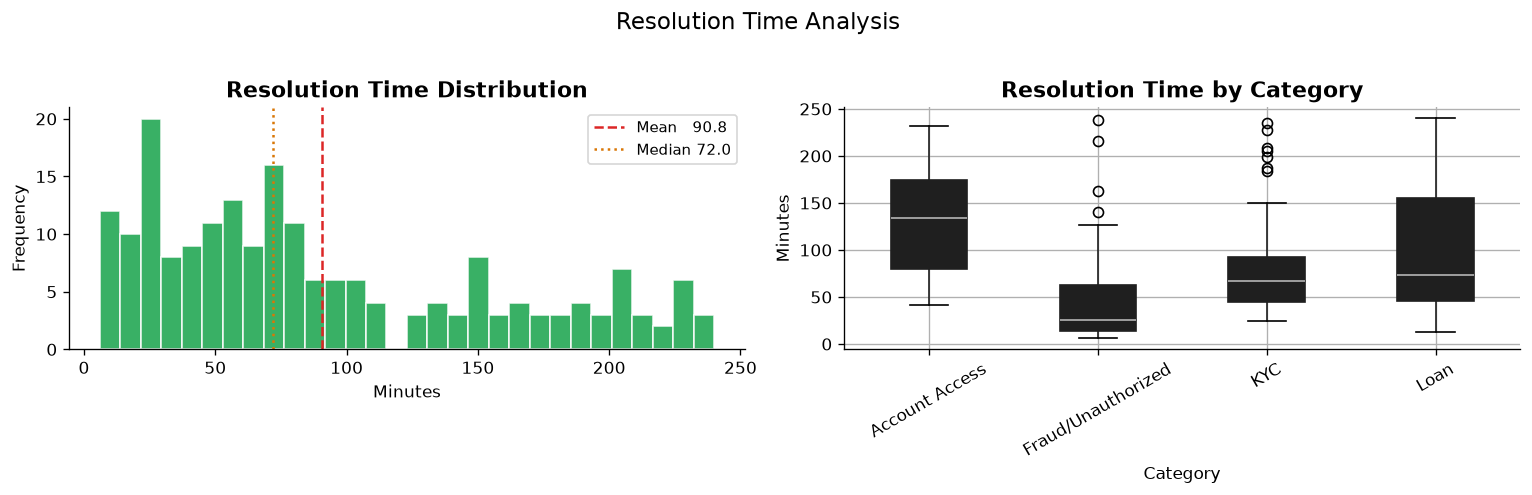


Resolution time stats (minutes):


,count,mean,std,min,25%,50%,75%,max
resolution_time_minutes,200.0,90.8,66.2,6.0,38.5,72.0,140.5,240.0


In [22]:
# ── Resolution time distribution ──────────────────────────────────────────────
res_time = tickets["resolution_time_minutes"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(res_time, bins=30, color=PALETTE[1], edgecolor="white", alpha=0.85)
axes[0].axvline(res_time.mean(),   color=PALETTE[2], linestyle="--",
                label=f"Mean   {res_time.mean():.1f}")
axes[0].axvline(res_time.median(), color=PALETTE[3], linestyle=":",
                label=f"Median {res_time.median():.1f}")
axes[0].set_title("Resolution Time Distribution")
axes[0].set_xlabel("Minutes")
axes[0].set_ylabel("Frequency")
axes[0].legend(fontsize=9)

# Box plot by category
tickets.boxplot(column="resolution_time_minutes", by="category",
                ax=axes[1], patch_artist=True)
axes[1].set_title("Resolution Time by Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Minutes")
axes[1].tick_params(axis="x", rotation=30)
plt.sca(axes[1])
plt.title("Resolution Time by Category")

plt.suptitle("Resolution Time Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nResolution time stats (minutes):")
display(res_time.describe().rename("resolution_time_minutes").to_frame().T.round(1))

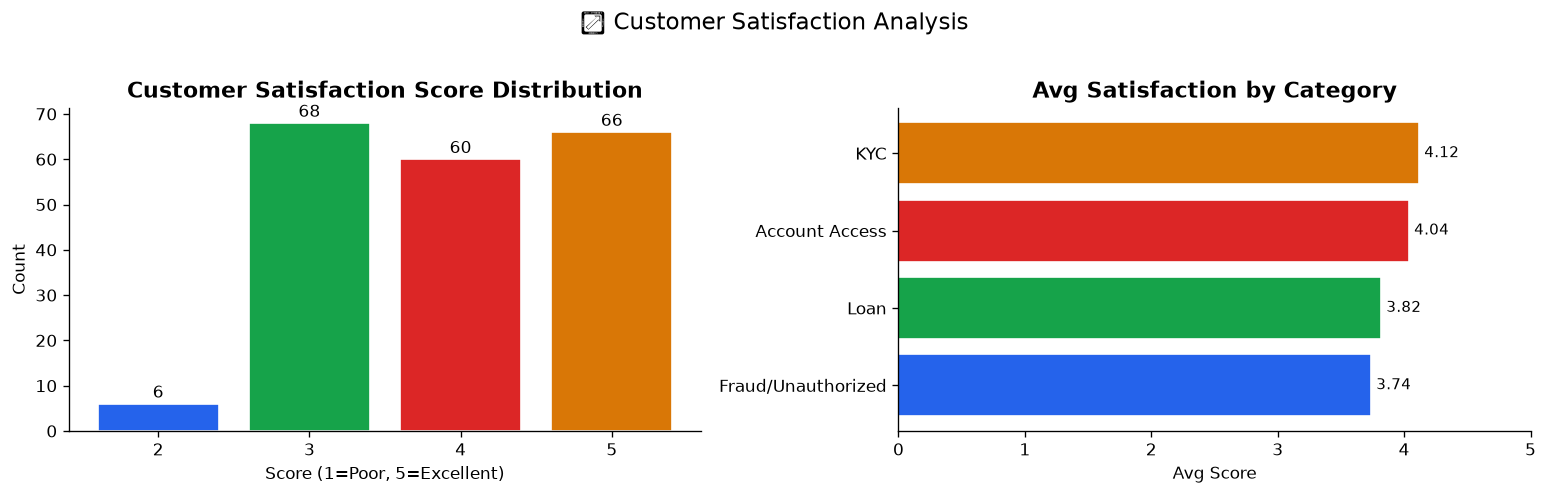


Customer satisfaction stats:


,count,mean,std,min,25%,50%,75%,max
customer_satisfaction,200.0,3.93,0.89,2.0,3.0,4.0,5.0,5.0


In [23]:
# ── Customer satisfaction distribution ────────────────────────────────────────
sat = tickets["customer_satisfaction"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Count bar (1–5 scale)
sat_counts = sat.value_counts().sort_index()
bars = axes[0].bar(sat_counts.index.astype(str), sat_counts.values,
                   color=PALETTE[:len(sat_counts)], edgecolor="white")
axes[0].set_title("Customer Satisfaction Score Distribution")
axes[0].set_xlabel("Score (1=Poor, 5=Excellent)")
axes[0].set_ylabel("Count")
for bar, val in zip(bars, sat_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5, str(val),
                 ha="center", va="bottom", fontsize=10)

# Avg satisfaction by category
sat_cat = tickets.groupby("category")["customer_satisfaction"].mean().sort_values()
bars2 = axes[1].barh(sat_cat.index, sat_cat.values,
                     color=PALETTE[:len(sat_cat)], edgecolor="white")
axes[1].bar_label(bars2, fmt="%.2f", padding=3, fontsize=9)
axes[1].set_xlim(0, 5)
axes[1].set_title("Avg Satisfaction by Category")
axes[1].set_xlabel("Avg Score")

plt.suptitle("⭐ Customer Satisfaction Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nCustomer satisfaction stats:")
display(sat.describe().rename("customer_satisfaction").to_frame().T.round(2))

In [24]:
# ── Null map ─────────────────────────────────────────────────────────────────
plot_nulls(tickets, "Support Tickets")


  ✅ No nulls found in Support Tickets


## 3 · Transactions  (`02_transactions.csv`)

In [25]:
txn = pd.read_csv(TXN_PATH)
_ = quick_profile(txn, "Transactions")



  Profile — Transactions  (2,000 rows × 16 cols)


,dtype,non_null,null_count,null_pct,unique,sample_values
column,,,,,,
transaction_id,object,2000,0,0.0,2000,"['TXN500001', 'TXN500002', 'TXN500003']"
account_id,object,2000,0,0.0,299,"['ACC995993', 'ACC163182', 'ACC107161']"
timestamp,object,2000,0,0.0,1999,"['2023-05-21 01:35:00', '2023-09-26 10:44:00',..."
amount_inr,float64,2000,0,0.0,1996,"[7553.61, 634.78, 1136.71]"
merchant_name,object,2000,0,0.0,21,"['Flipkart', 'Zomato', 'VPN_Service_Anon']"
merchant_category,object,2000,0,0.0,13,"['E-commerce', 'Food Delivery', 'Digital']"
transaction_type,object,2000,0,0.0,7,"['Credit Card', 'UPI', 'Debit Card']"
city,object,2000,0,0.0,14,"['Mumbai', 'Chennai', 'Hyderabad']"
hour_of_day,int64,2000,0,0.0,24,"[1, 10, 2]"


In [26]:
# ── Numeric columns descriptive stats ─────────────────────────────────────────
num_cols_txn = txn.select_dtypes(include=[np.number]).columns.tolist()

print("Numeric columns descriptive stats — Transactions:")
display(txn[num_cols_txn].describe().T.round(2))

Numeric columns descriptive stats — Transactions:


,count,mean,std,min,25%,50%,75%,max
amount_inr,2000.0,5466.72,9571.40,50.18,765.41,1486.9,6009.8,49979.31
hour_of_day,2000.0,11.29,6.86,0.00,5.00,11.0,17.0,23.00
fraud_label,2000.0,0.12,0.33,0.00,0.00,0.0,0.0,1.00


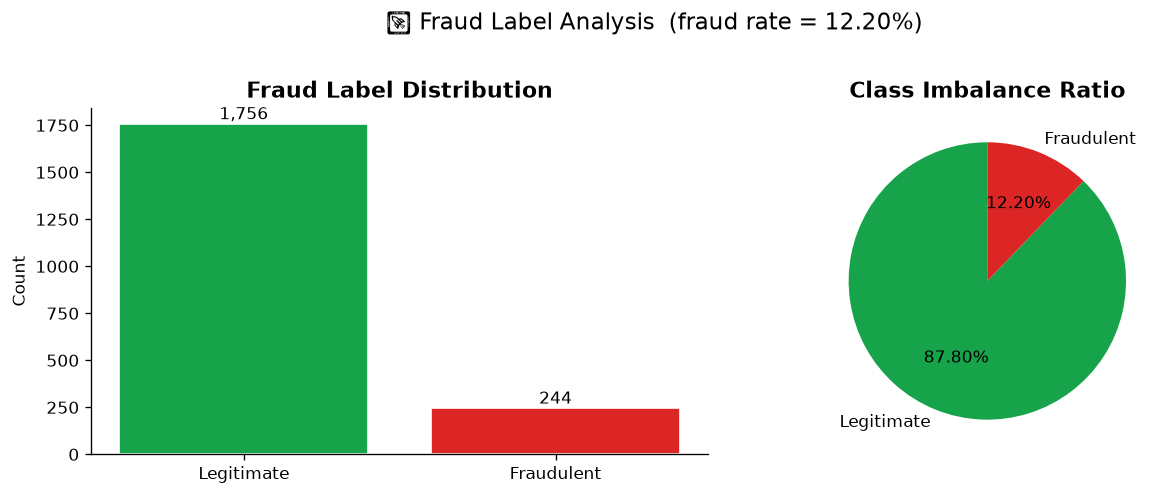

Imbalance ratio → 1,756 legitimate : 244 fraud


In [27]:
# ── Fraud label balance ───────────────────────────────────────────────────────
fraud_counts = txn["fraud_label"].value_counts()
labels = {0: "Legitimate", 1: "Fraudulent"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar
colors = [PALETTE[1], PALETTE[2]]
bars = axes[0].bar(
    [labels[k] for k in fraud_counts.index],
    fraud_counts.values,
    color=colors,
    edgecolor="white"
)
axes[0].set_title("Fraud Label Distribution")
axes[0].set_ylabel("Count")
for bar, val in zip(bars, fraud_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 5, f"{val:,}",
                 ha="center", va="bottom", fontsize=10)

# Pie
axes[1].pie(
    fraud_counts.values,
    labels=[labels[k] for k in fraud_counts.index],
    autopct="%1.2f%%",
    colors=colors,
    startangle=90
)
axes[1].set_title("Class Imbalance Ratio")

pct_fraud = fraud_counts[1] / len(txn) * 100
plt.suptitle(f"🚨 Fraud Label Analysis  (fraud rate = {pct_fraud:.2f}%)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Imbalance ratio → {fraud_counts[0]:,} legitimate : {fraud_counts[1]:,} fraud")

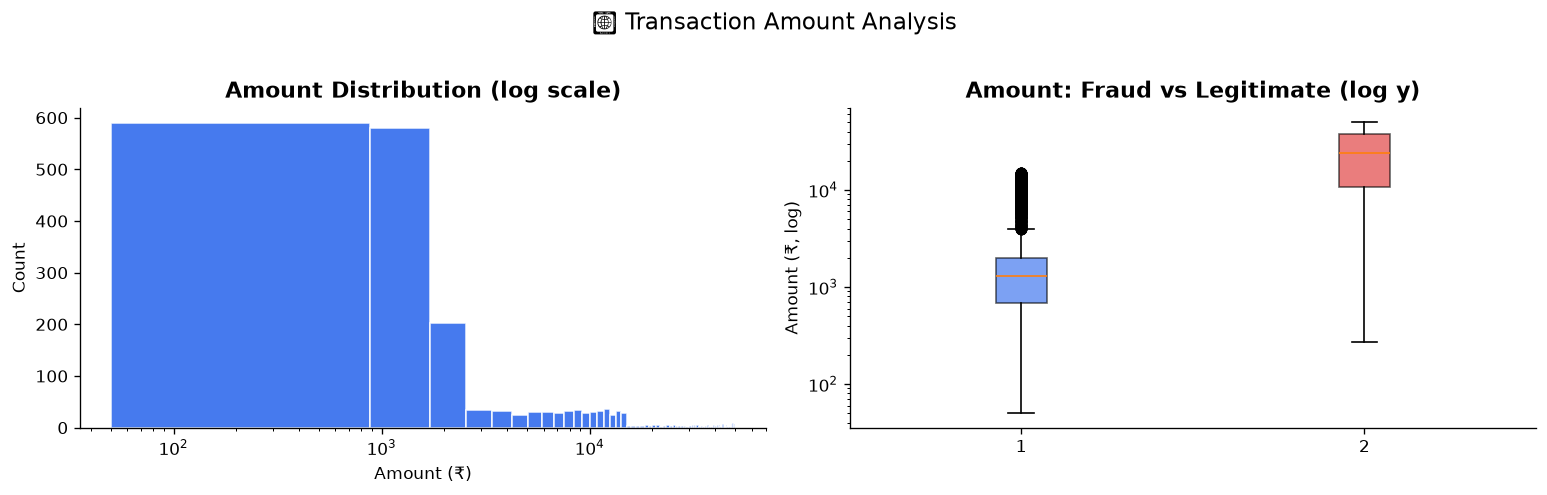


Amount stats by fraud label:


,count,mean,std,min,25%,50%,75%,max
fraud_label,,,,,,,,
0,1756.0,2815.83,3738.22,50.18,678.43,1306.43,1980.1,14999.40
1,244.0,24544.40,15377.47,272.28,10664.69,23887.62,38150.6,49979.31


In [28]:
# ── Amount distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Overall histogram (log scale)
axes[0].hist(txn["amount_inr"], bins=60, color=PALETTE[0], edgecolor="white", alpha=0.85)
axes[0].set_xscale("log")
axes[0].set_title("Amount Distribution (log scale)")
axes[0].set_xlabel("Amount (₹)")
axes[0].set_ylabel("Count")

# Fraud vs legitimate box plot
fraud_amounts = txn[txn["fraud_label"] == 1]["amount_inr"]
legit_amounts = txn[txn["fraud_label"] == 0]["amount_inr"]

bp = axes[1].boxplot(
    [legit_amounts, fraud_amounts],
    label=["Legitimate", "Fraudulent"],
    patch_artist=True,
    boxprops=dict(facecolor=PALETTE[0], alpha=0.6)
)
bp["boxes"][1].set_facecolor(PALETTE[2])
axes[1].set_yscale("log")
axes[1].set_title("Amount: Fraud vs Legitimate (log y)")
axes[1].set_ylabel("Amount (₹, log)")

plt.suptitle("💰 Transaction Amount Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nAmount stats by fraud label:")
display(txn.groupby("fraud_label")["amount_inr"].describe().round(2))

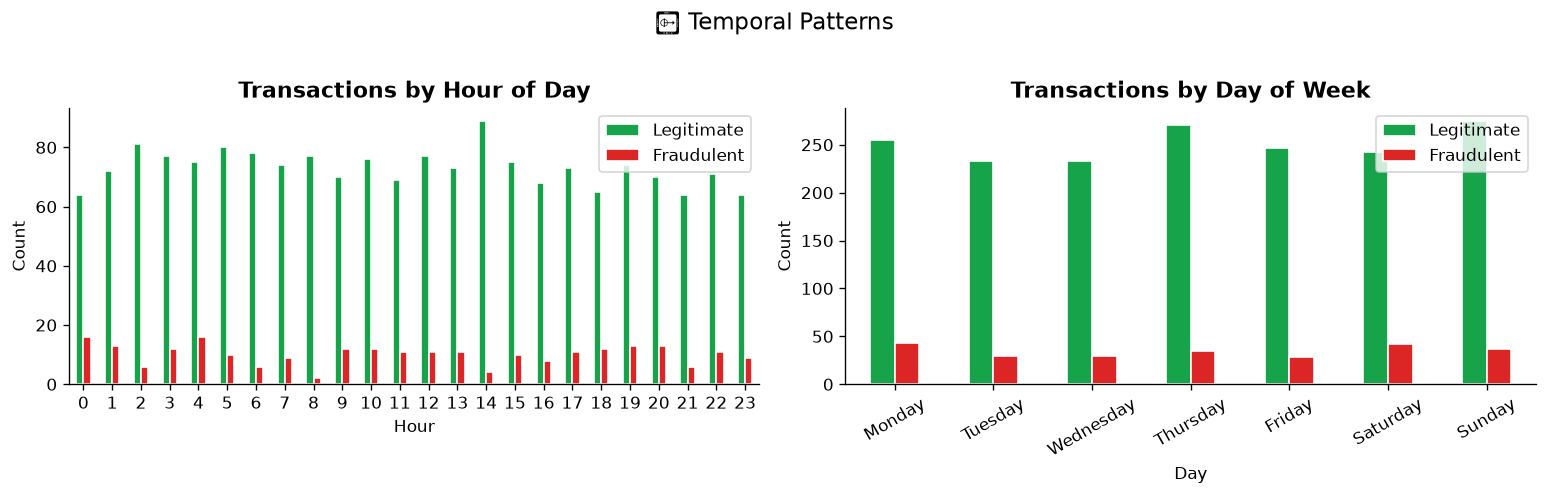

In [29]:
# ── Temporal patterns ─────────────────────────────────────────────────────────
txn["timestamp"] = pd.to_datetime(txn["timestamp"], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Hour of day
hour_counts = txn.groupby(["hour_of_day", "fraud_label"]).size().unstack(fill_value=0)
hour_counts.columns = ["Legitimate", "Fraudulent"]
hour_counts.plot(kind="bar", ax=axes[0], color=[PALETTE[1], PALETTE[2]], edgecolor="white")
axes[0].set_title("Transactions by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=0)

# Day of week
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_counts = txn.groupby(["day_of_week", "fraud_label"]).size().unstack(fill_value=0)
dow_counts.columns = ["Legitimate", "Fraudulent"]
dow_counts = dow_counts.reindex(dow_order)
dow_counts.plot(kind="bar", ax=axes[1], color=[PALETTE[1], PALETTE[2]], edgecolor="white")
axes[1].set_title("Transactions by Day of Week")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend()

plt.suptitle("⏰ Temporal Patterns", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

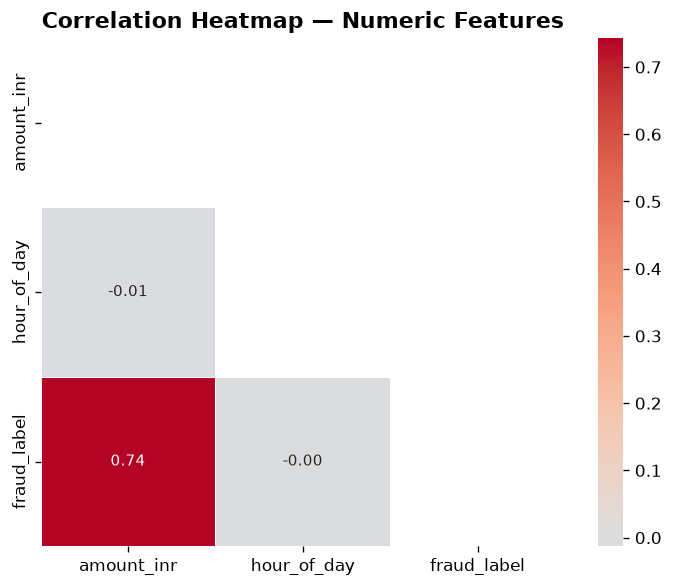

In [30]:
# ── Correlation heatmap (numeric features) ───────────────────────────────────
num_cols = txn.select_dtypes(include=[np.number]).columns.tolist()

if len(num_cols) > 1:
    corr = txn[num_cols].corr()
    fig, ax = plt.subplots(figsize=(max(6, len(num_cols)), max(5, len(num_cols)-1)))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, mask=mask, ax=ax,
                linewidths=0.4, annot_kws={"size": 9})
    ax.set_title("Correlation Heatmap — Numeric Features")
    plt.tight_layout()
    plt.show()




Date range: 2023-01-01 00:42:00 → 2023-12-31 23:52:00
Span: 364 days


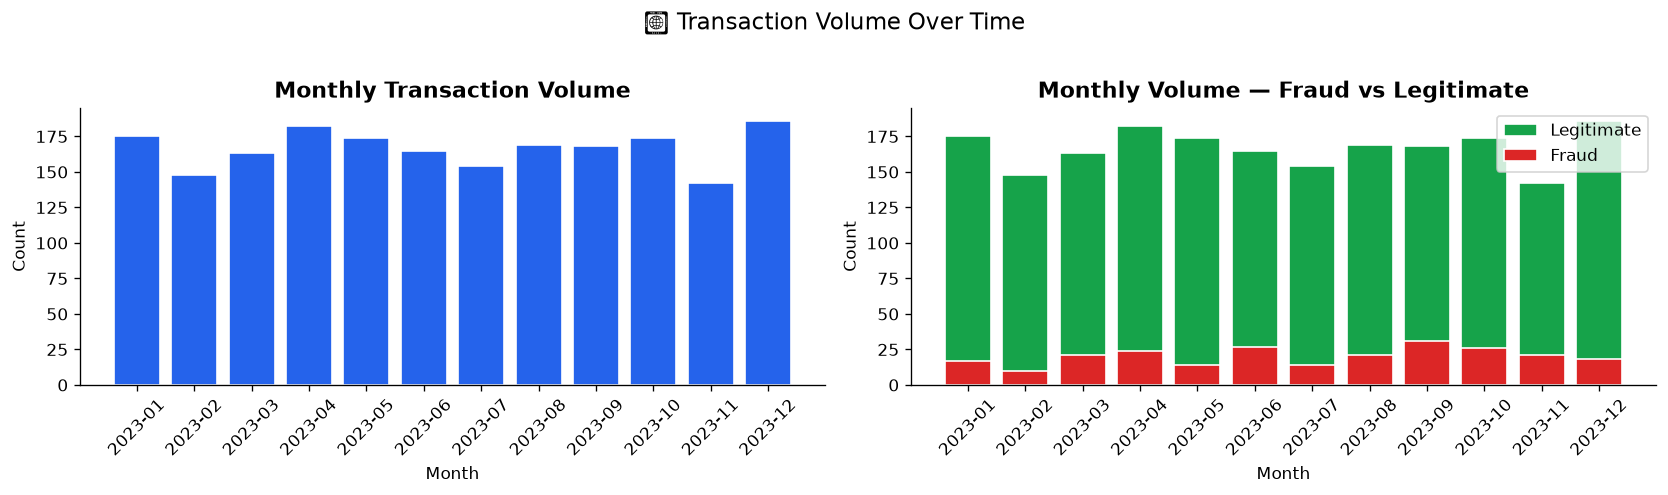

In [31]:
# ── Timestamp analysis ────────────────────────────────────────────────────────
txn["timestamp"] = pd.to_datetime(txn["timestamp"], errors="coerce")

print(f"Date range: {txn['timestamp'].min()} → {txn['timestamp'].max()}")
print(f"Span: {(txn['timestamp'].max() - txn['timestamp'].min()).days} days")

# Monthly transaction volume
txn["year_month"] = txn["timestamp"].dt.to_period("M")
monthly_txn = txn.groupby("year_month").size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Monthly volume
axes[0].bar(monthly_txn.index.astype(str), monthly_txn.values,
            color=PALETTE[0], edgecolor="white")
axes[0].set_title("Monthly Transaction Volume")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Monthly fraud count overlay
monthly_fraud = txn[txn["fraud_label"] == 1].groupby("year_month").size()
axes[1].bar(monthly_txn.index.astype(str), monthly_txn.values,
            color=PALETTE[1], edgecolor="white", label="Legitimate")
axes[1].bar(monthly_fraud.index.astype(str), monthly_fraud.values,
            color=PALETTE[2], edgecolor="white", label="Fraud")
axes[1].set_title("Monthly Volume — Fraud vs Legitimate")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.suptitle("📅 Transaction Volume Over Time", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Clean up temp column
txn.drop(columns=["year_month"], errors="ignore", inplace=True)

In [32]:
# ── Categorical columns distribution ─────────────────────────────────────────
cat_cols_txn = [c for c in txn.columns if is_categorical(txn[c])]
cat_cols_txn = [c for c in cat_cols_txn 
                if str(txn[c].dtype) == "str" 
                and txn[c].dropna().str.len().mean() < 35]

# Exclude ID-like and label columns handled separately
exclude = ["transaction_id", "account_id", "fraud_label", "fraud_reason"]
cat_cols_txn = [c for c in cat_cols_txn if c not in exclude]

print(f"Detected {len(cat_cols_txn)} categorical columns: {cat_cols_txn}")

TOP_N = 10
CARDINALITY_LIMIT = 13

for cat_col in cat_cols_txn:
    counts = txn[cat_col].value_counts()
    labels = [str(v) for v in counts.index]
    values = counts.values
    n_unique = len(labels)
    high_cardinality = n_unique > CARDINALITY_LIMIT

    if high_cardinality:
        top_labels = labels[:TOP_N]
        top_values = values[:TOP_N]

        fig, ax = plt.subplots(figsize=(10, 4))
        x = range(len(top_labels))
        bars = ax.bar(x, top_values, color=PALETTE[:len(top_values)], edgecolor="white")
        ax.set_xticks(list(x))
        ax.set_xticklabels(top_labels, rotation=30, ha="right")
        ax.set_ylabel("Count")
        for bar, val in zip(bars, top_values):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1, str(val),
                    ha="center", va="bottom", fontsize=9)
        plt.suptitle(f"📋 {cat_col}  —  top {TOP_N} of {n_unique} unique values",
                     fontsize=13, y=1.02)
        plt.tight_layout()
        plt.show()

    else:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))

        x = range(len(labels))
        bars = axes[0].bar(x, values, color=PALETTE[:len(values)], edgecolor="white")
        axes[0].set_xticks(list(x))
        axes[0].set_xticklabels(labels, rotation=30, ha="right")
        axes[0].set_title(f"Count by {cat_col}")
        axes[0].set_ylabel("Count")
        for bar, val in zip(bars, values):
            axes[0].text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + 1, str(val),
                         ha="center", va="bottom", fontsize=9)

        axes[1].pie(values, labels=labels,
                    autopct="%1.1f%%", colors=PALETTE[:len(values)],
                    startangle=45, pctdistance=0.8)
        axes[1].set_title(f"Share by {cat_col}")

        plt.suptitle(f"📊 Transaction Distribution — {cat_col}", fontsize=13, y=1.02)
        plt.tight_layout()
        plt.show()

    print(f"\nValue counts — {cat_col}  ({n_unique} unique):")
    display(counts.to_frame("count"))

Detected 0 categorical columns: []


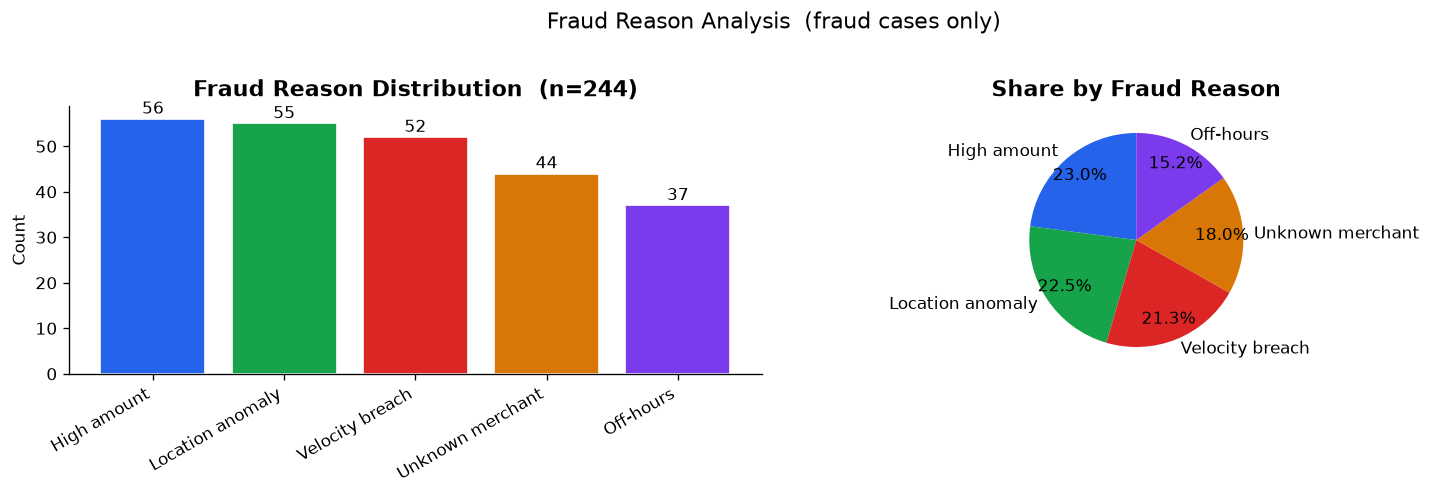


Fraud reason counts  (244 fraud transactions):


,count
fraud_reason,
High amount,56
Location anomaly,55
Velocity breach,52
Unknown merchant,44
Off-hours,37


In [33]:
# ── Fraud reason analysis (non-null only) ────────────────────────────────────
fraud_reasons = txn["fraud_reason"].dropna()
reason_counts = fraud_reasons.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x = range(len(reason_counts))
bars = axes[0].bar(x, reason_counts.values,
                   color=PALETTE[:len(reason_counts)], edgecolor="white")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels([str(v) for v in reason_counts.index], rotation=30, ha="right")
axes[0].set_title(f"Fraud Reason Distribution  (n={len(fraud_reasons)})")
axes[0].set_ylabel("Count")
for bar, val in zip(bars, reason_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3, str(val),
                 ha="center", va="bottom", fontsize=10)

axes[1].pie(reason_counts.values,
            labels=[str(v) for v in reason_counts.index],
            autopct="%1.1f%%", colors=PALETTE[:len(reason_counts)],
            startangle=90, pctdistance=0.8)
axes[1].set_title("Share by Fraud Reason")

plt.suptitle("Fraud Reason Analysis  (fraud cases only)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nFraud reason counts  ({len(fraud_reasons)} fraud transactions):")
display(reason_counts.to_frame("count"))

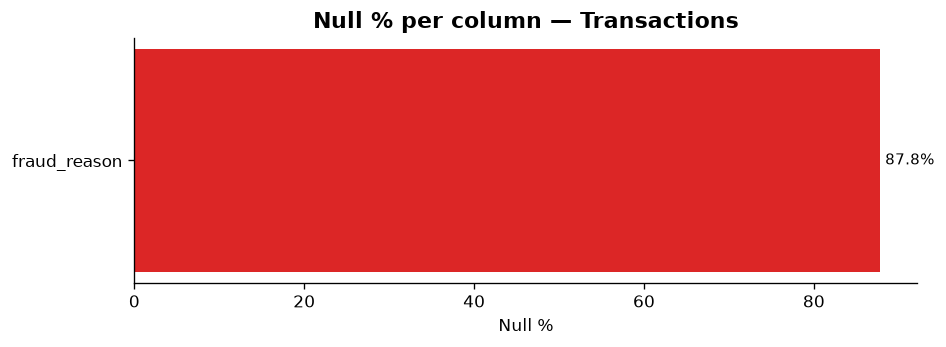

In [34]:
# ── Null map ──────────────────────────────────────────────────────────────────
plot_nulls(txn, "Transactions")

## 4 · QA Pairs  (`04_qa_pairs.json`)

In [35]:
with open(QA_PATH) as f:
    qa_raw = json.load(f)

print(f"Total QA pairs: {len(qa_raw)}")
print("\nFirst item:")
print(json.dumps(qa_raw[0], indent=2, ensure_ascii=False))

qa_df = pd.json_normalize(qa_raw)
print(f"\nFlattened shape: {qa_df.shape}")
display(qa_df.head(3))



Total QA pairs: 20

First item:
{
  "id": "QA001",
  "category": "Fraud",
  "question": "I noticed an unauthorized transaction of ₹15,000 on my account. What should I do?",
  "answer": "Please report immediately via our 24x7 helpline or mobile app. We will block your card, raise a dispute, and if reported within 3 working days, you have zero liability under RBI guidelines. A provisional credit will be issued within 10 working days.",
  "policy_ref": "Fraud Handling Policy §3, §4",
  "risk_level": "High",
  "suggested_action": "Block card, raise dispute, escalate to fraud team"
}

Flattened shape: (20, 7)


,id,category,question,answer,policy_ref,risk_level,suggested_action
0,QA001,Fraud,"I noticed an unauthorized transaction of ₹15,0...",Please report immediately via our 24x7 helplin...,"Fraud Handling Policy §3, §4",High,"Block card, raise dispute, escalate to fraud team"
1,QA002,Fraud,How long does fraud investigation take?,Fraud investigations are completed within 30-4...,Fraud Handling Policy §4,Medium,Update customer with reference number
2,QA003,Fraud,Someone used my OTP to transfer money. Can I g...,"If the OTP was shared voluntarily, liability m...","Fraud Handling Policy §3.2, §6",High,"Suspend account access, escalate to fraud team..."


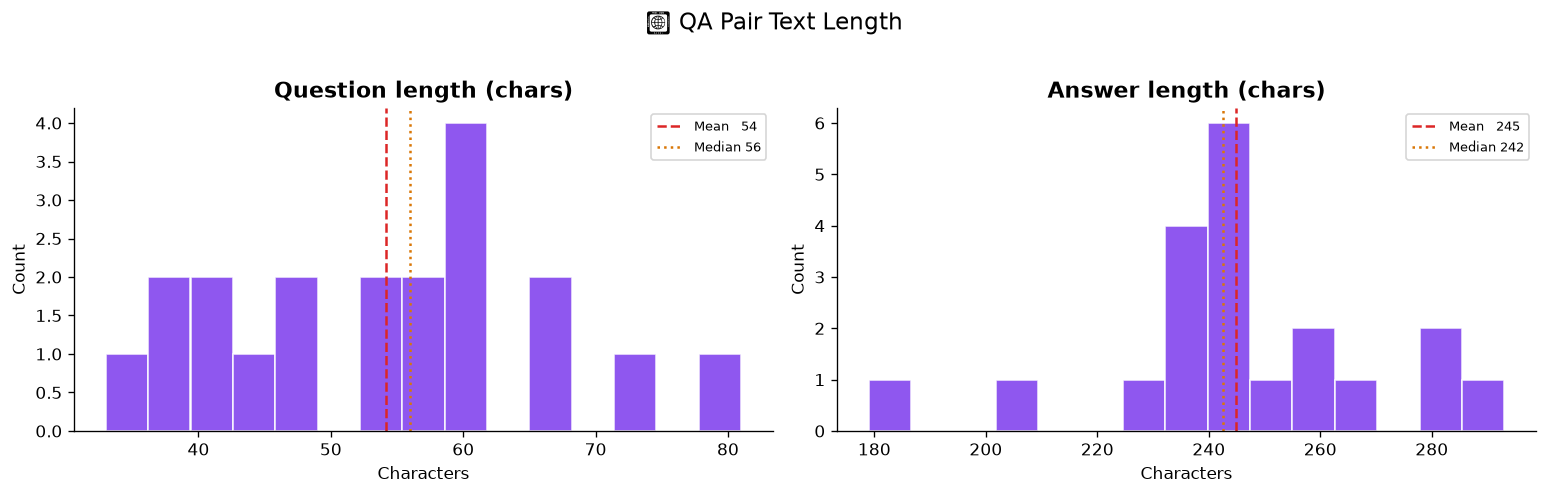


Text length stats:


,count,mean,std,min,25%,50%,75%,max
question,20.0,54.2,12.5,33.0,44.2,56.0,61.0,81.0
answer,20.0,244.8,24.9,179.0,235.8,242.5,256.8,293.0


In [36]:
# ── QA text length analysis ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, label in zip(axes, ["question", "answer"], ["Question", "Answer"]):
    lengths = qa_df[col].dropna().str.len()
    ax.hist(lengths, bins=15, color=PALETTE[4], edgecolor="white", alpha=0.85)
    ax.axvline(lengths.mean(),   color=PALETTE[2], linestyle="--",
               label=f"Mean   {lengths.mean():.0f}")
    ax.axvline(lengths.median(), color=PALETTE[3], linestyle=":",
               label=f"Median {lengths.median():.0f}")
    ax.set_title(f"{label} length (chars)")
    ax.set_xlabel("Characters")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("📖 QA Pair Text Length", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nText length stats:")
display(qa_df[["question", "answer"]].apply(lambda c: c.str.len().describe()).T.round(1))


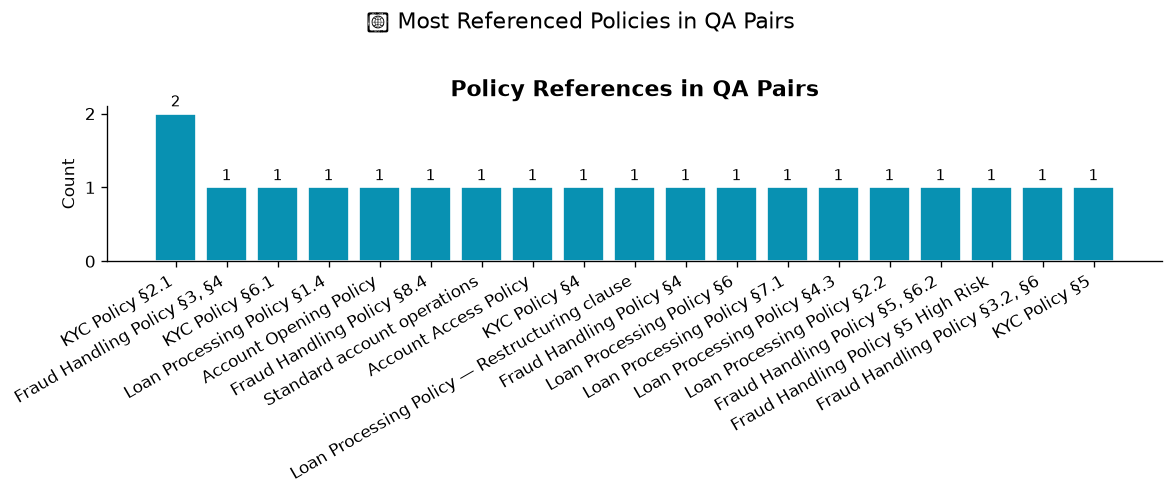


Policy reference counts:


,count
policy_ref,
KYC Policy §2.1,2
"Fraud Handling Policy §3, §4",1
KYC Policy §6.1,1
Loan Processing Policy §1.4,1
Account Opening Policy,1
Fraud Handling Policy §8.4,1
Standard account operations,1
Account Access Policy,1
KYC Policy §4,1


In [37]:
# ── Policy reference analysis ─────────────────────────────────────────────────
policy_counts = qa_df["policy_ref"].value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(policy_counts))
bars = ax.bar(x, policy_counts.values, color=PALETTE[5], edgecolor="white")
ax.set_xticks(list(x))
ax.set_xticklabels([str(v) for v in policy_counts.index], rotation=30, ha="right")
ax.set_ylabel("Count")
ax.set_title("Policy References in QA Pairs")
for bar, val in zip(bars, policy_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05, str(val),
            ha="center", va="bottom", fontsize=9)

plt.suptitle("📜 Most Referenced Policies in QA Pairs", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nPolicy reference counts:")
display(policy_counts.to_frame("count"))

In [38]:
# ── Null map ──────────────────────────────────────────────────────────────────
plot_nulls(qa_df, "QA Pairs")

  ✅ No nulls found in QA Pairs


## 5 · Policy Documents  (`policy_docs/`)


  Policy Documents — File Inventory


,file,type,size_kb,word_count,lines
0,fraud_handling_policy.txt,.txt,3.19,468,73
1,kyc_policy.txt,.txt,2.47,378,64
2,loan_processing_policy.txt,.txt,2.92,466,71
3,refund_dispute_policy.txt,.txt,1.97,292,43


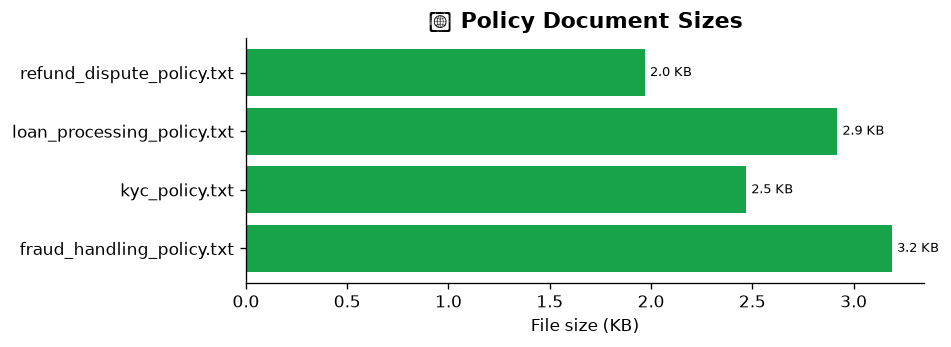

In [39]:
section("Policy Documents — File Inventory")

doc_stats = []
for fname in sorted(os.listdir(POLICY_DIR)):
    fpath = POLICY_DIR / fname
    size_kb = fpath.stat().st_size / 1024
    ext = fpath.suffix.lower()

    # Try reading text files for word/line count
    word_count = line_count = None
    if ext in (".txt", ".md"):
        try:
            text = fpath.read_text(errors="ignore")
            word_count = len(text.split())
            line_count = text.count("\n")
        except Exception:
            pass

    doc_stats.append({
        "file"      : fname,
        "type"      : ext,
        "size_kb"   : round(size_kb, 2),
        "word_count": word_count,
        "lines"     : line_count,
    })

docs_df = pd.DataFrame(doc_stats)
display(docs_df)

# ── Size bar chart ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, max(3, len(docs_df)*0.4)))
colors = [PALETTE[0] if t == ".pdf" else PALETTE[1] if t == ".txt" else PALETTE[4]
          for t in docs_df["type"]]
bars = ax.barh(docs_df["file"], docs_df["size_kb"], color=colors)
ax.bar_label(bars, fmt="%.1f KB", padding=3, fontsize=8)
ax.set_xlabel("File size (KB)")
ax.set_title("📄 Policy Document Sizes")
plt.tight_layout()
plt.show()


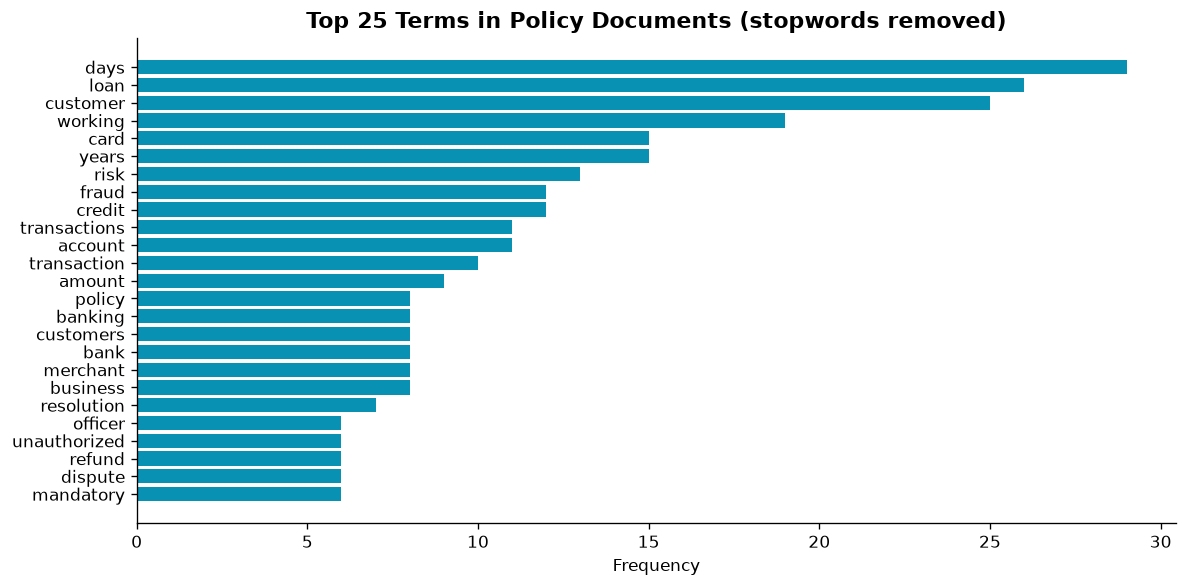

In [40]:
# ── Word frequency in TXT policy docs ────────────────────────────────────────
import re
from collections import Counter

STOPWORDS = {
    "the","a","an","in","of","to","and","or","is","are","be","for","this",
    "that","with","on","at","as","by","it","its","from","will","shall","may",
    "must","not","any","all","such","which","been","was","were","has","have",
    "their","they","we","our","you","your","if","so","when","than","more",
    "also","can","should","about","each","no","only","other","these","those",
    # ── additions ─────────────────────────────────────────────────────────────
    "within","without","upon","under","over","after","before","between",
    "through","into","onto","per","via","please","contact","provide",
    "ensure","make","use","used","using","based","required","related",
}

combined_text = ""
for fname in os.listdir(POLICY_DIR):
    fpath = POLICY_DIR / fname
    if fpath.suffix.lower() in (".txt", ".md"):
        combined_text += fpath.read_text(errors="ignore") + " "

if combined_text.strip():
    words = re.findall(r"\b[a-z]{4,}\b", combined_text.lower())
    word_freq = Counter(w for w in words if w not in STOPWORDS)
    top_words = word_freq.most_common(25)

    words_list, freq_list = zip(*top_words)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(list(reversed(words_list)), list(reversed(freq_list)),
            color=PALETTE[5])
    ax.set_title("Top 25 Terms in Policy Documents (stopwords removed)")
    ax.set_xlabel("Frequency")
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️  No .txt/.md policy files found — skipping word frequency chart")


## 6 · Cross-Dataset Summary & RAG Readiness

In [41]:
section("Dataset Summary — RAG Readiness Check")

summary = pd.DataFrame([
    {
        "Dataset"      : "Support Tickets",
        "Rows"         : f"{len(tickets):,}",
        "Null %"       : f"{tickets.isnull().mean().mean()*100:.1f}%",
        "Use in system": "Intent classification · RAG retrieval source",
        "RAG ready?"   : "✅ After text cleaning",
    },
    {
        "Dataset"      : "Transactions",
        "Rows"         : f"{len(txn):,}",
        "Null %"       : f"{txn.isnull().mean().mean()*100:.1f}%",
        "Use in system": "Fraud risk classification · context enrichment",
        "RAG ready?"   : "⚙️  Needs feature engineering",
    },
    {
        "Dataset"      : "QA Pairs",
        "Rows"         : f"{len(qa_df):,}",
        "Null %"       : f"{qa_df.isnull().mean().mean()*100:.1f}%",
        "Use in system": "RAG knowledge base (primary Q&A source)",
        "RAG ready?"   : "✅ Direct embedding candidate",
    },
    {
        "Dataset"      : "Policy Docs",
        "Rows"         : f"{len(docs_df)} files",
        "Null %"       : "N/A",
        "Use in system": "RAG policy retrieval",
        "RAG ready?"   : "✅ After chunking + embedding",
    },
])
display(summary.set_index("Dataset"))



  Dataset Summary — RAG Readiness Check


,Rows,Null %,Use in system,RAG ready?
Dataset,,,,
Support Tickets,200,0.0%,Intent classification · RAG retrieval source,✅ After text cleaning
Transactions,"2,000",5.5%,Fraud risk classification · context enrichment,⚙️ Needs feature engineering
QA Pairs,20,0.0%,RAG knowledge base (primary Q&A source),✅ Direct embedding candidate
Policy Docs,4 files,N/A,RAG policy retrieval,✅ After chunking + embedding



## 📊 Data Profiling Summary — AI-Powered Banking Support & Fraud Intelligence System

### Datasets Profiled
| Dataset | Rows | Nulls | Coverage |
|---|---|---|---|
| Support Tickets | 200 | 0% | Jan–Dec 2023 |
| Transactions | 2,000 | 5.5% (fraud_reason only) | Jan–Dec 2023 |
| QA Pairs | 20 | 0% | 4 categories |
| Policy Docs | 4 files | N/A | 1,604 words total |

### Key Findings
- **Support Tickets** — Zero nulls, 4 categories (Fraud, Loan, KYC, General), avg resolution 90.78 min, customer satisfaction 3.93/5
- **Transactions** — 12.2% fraud rate (imbalanced), fraud transactions avg ₹24,544 vs legitimate ₹2,815, 5 fraud reasons evenly distributed
- **QA Pairs** — Rich structure (question, answer, policy_ref, suggested_action), direct RAG embedding candidate
- **Policy Docs** — 4 text files, fraud_handling_policy largest (468 words), all ready for chunking

### Next Steps — Preprocessing & RAG Pipeline

📌 **Support Tickets**
1. Clean query_text (lowercase, remove special chars)
2. Encode category label → integer for intent classifier
3. Split into train/val/test (stratified by category)
4. Embed text with all-MiniLM-L6-v2 → store in FAISS

📌 **Transactions**
1. Parse timestamp → extract hour, day_of_week, month
2. Handle class imbalance with SMOTE or class_weight
3. Scale numeric features (StandardScaler)
4. Engineer features from velocity_flag, geo_anomaly_flag, high_amount_flag

📌 **QA Pairs**
1. Concatenate question + answer as RAG document chunks
2. Embed each pair → upsert into FAISS index

📌 **Policy Docs**
1. Chunk text (~512 tokens with 64-token overlap)
2. Embed chunks → upsert into FAISS index
